Temperatura crítica Tc = 3.313


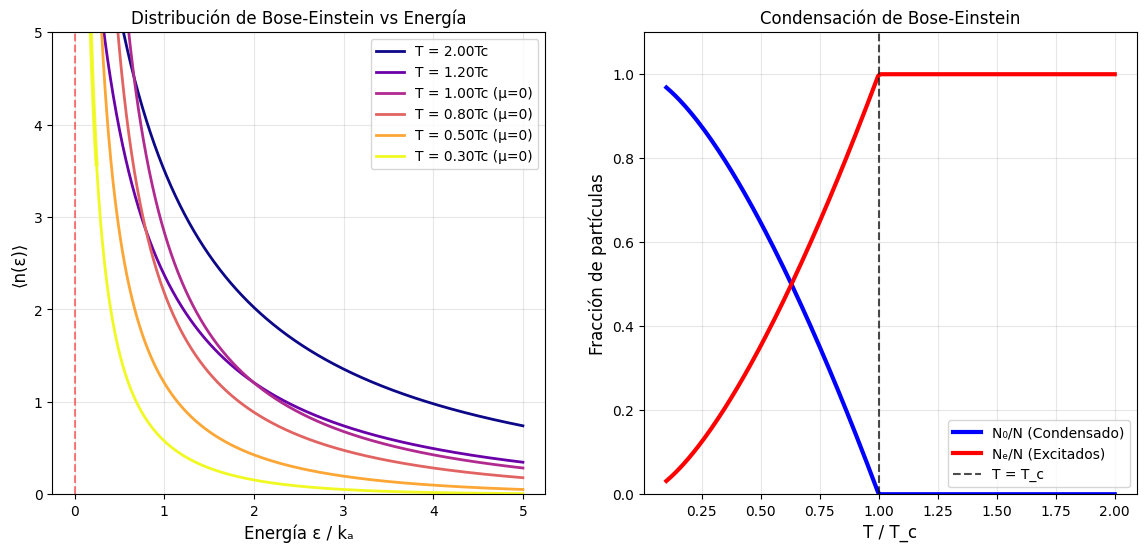

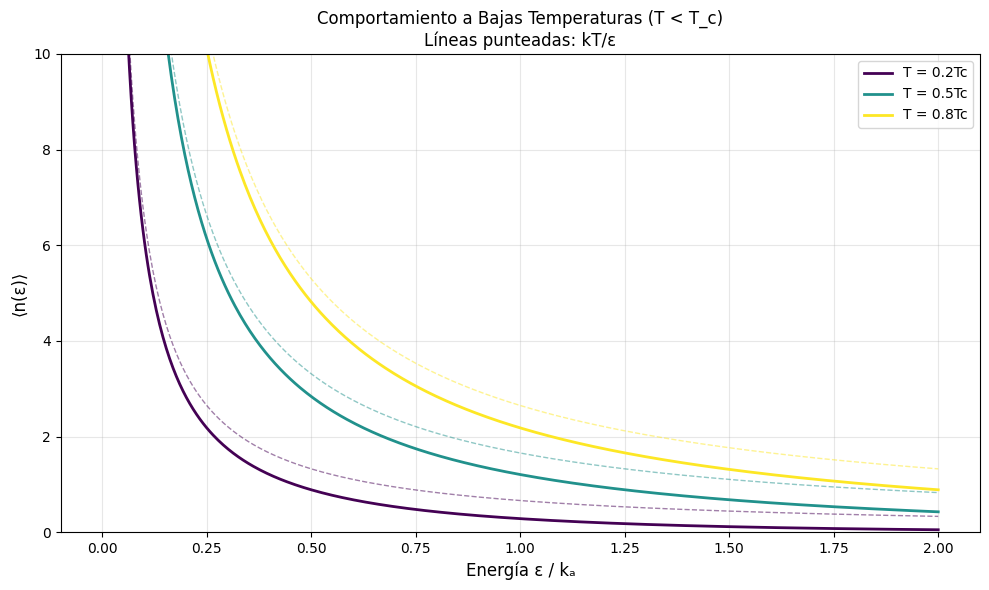

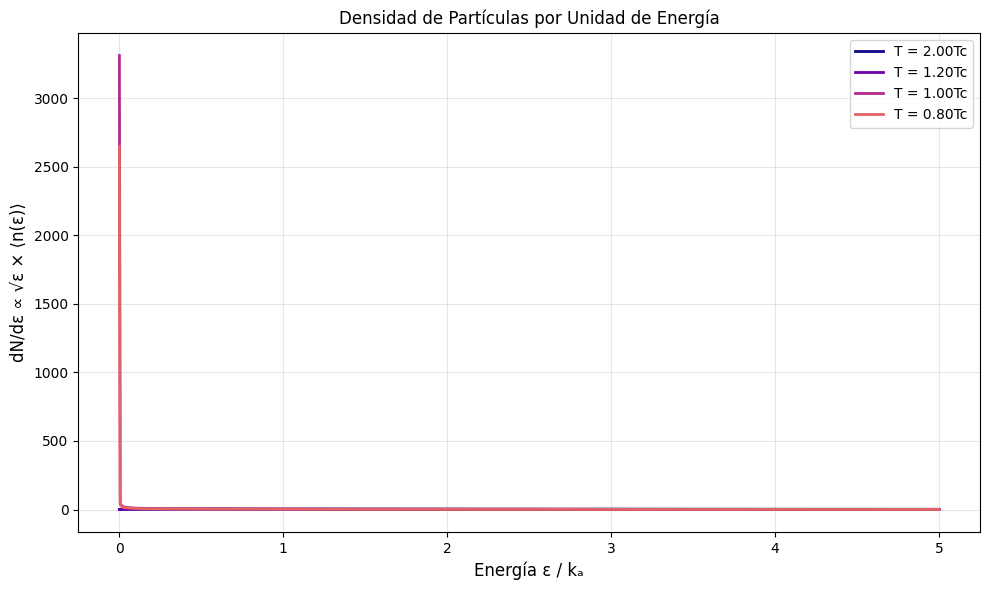


RESUMEN NUMÉRICO
Temperatura crítica: Tc = 3.313

Fracción en el condensado para diferentes T:
T/Tc = 0.1: N₀/N = 0.968
T/Tc = 0.5: N₀/N = 0.646
T/Tc = 0.8: N₀/N = 0.284
T/Tc = 1.0: N₀/N = 0.000
T/Tc = 1.2: No hay condensado


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import zeta
import matplotlib.colors as mcolors

# Configuración de estilo
plt.style.use('default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12

def bose_einstein(energy, temp, mu, kB=1):
    """
    Distribución de Bose-Einstein
    """
    with np.errstate(over='ignore', invalid='ignore'):
        exponent = (energy - mu) / (kB * temp)
        # Evitar división por cero
        distribution = np.where(exponent > 50, 0, 1.0 / (np.exp(exponent) - 1))
        distribution = np.where(distribution < 0, 0, distribution)
    return distribution

def critical_temperature(n, m, hbar=1, kB=1):
    """
    Calcular temperatura crítica para BEC
    """
    return (2 * np.pi * hbar**2 / m) * (n / zeta(3/2))**(2/3)

# Parámetros del sistema
n = 1.0  # densidad
m = 1.0  # masa
hbar = 1.0
kB = 1.0

# Calcular temperatura crítica
Tc = critical_temperature(n, m, hbar, kB)
print(f"Temperatura crítica Tc = {Tc:.3f}")

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# =============================================
# PRIMER GRÁFICO: Distribución vs Energía
# =============================================

# Rangos de energía
energy = np.linspace(0, 5, 1000)
energy[0] = 1e-6  # Evitar división por cero en epsilon=0

# Temperaturas a graficar
temperatures = [2.0 * Tc, 1.2 * Tc, Tc, 0.8 * Tc, 0.5 * Tc, 0.3 * Tc]
colors = plt.cm.plasma(np.linspace(0, 1, len(temperatures)))

for i, T in enumerate(temperatures):
    if T > Tc:
        # Para T > Tc: μ < 0
        mu = -0.1 * kB * T  # Aproximación simple
    else:
        # Para T <= Tc: μ ≈ 0
        mu = 0.0
    
    distribution = bose_einstein(energy, T, mu, kB)
    
    label = f'T = {T/Tc:.2f}Tc'
    if T <= Tc:
        label += ' (μ=0)'
    
    ax1.plot(energy, distribution, color=colors[i], linewidth=2, label=label)
    
    # Destacar el comportamiento a bajas energías
    if T <= Tc:
        ax1.plot(energy[:50], distribution[:50], color=colors[i], 
                linewidth=3, alpha=0.8)

ax1.set_xlabel('Energía ε / kₐ')
ax1.set_ylabel('⟨n(ε)⟩')
ax1.set_title('Distribución de Bose-Einstein vs Energía')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 5)

# Línea vertical para Tc
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='ε = 0')

# =============================================
# SEGUNDO GRÁFICO: Ocupación del estado base
# =============================================

# Temperaturas para el segundo gráfico
T_range = np.linspace(0.1, 2.0, 200) * Tc

# Fracción en el condensado
condensate_fraction = np.zeros_like(T_range)
for i, T in enumerate(T_range):
    if T <= Tc:
        condensate_fraction[i] = 1 - (T/Tc)**(3/2)
    else:
        condensate_fraction[i] = 0

# Número de partículas en estados excitados
excited_fraction = 1 - condensate_fraction

ax2.plot(T_range/Tc, condensate_fraction, 'b-', linewidth=3, 
         label='N₀/N (Condensado)')
ax2.plot(T_range/Tc, excited_fraction, 'r-', linewidth=3, 
         label='Nₑ/N (Excitados)')
ax2.axvline(x=1, color='k', linestyle='--', alpha=0.7, 
           label='T = T_c')

ax2.set_xlabel('T / T_c')
ax2.set_ylabel('Fracción de partículas')
ax2.set_title('Condensación de Bose-Einstein')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.1)

# =============================================
# TERCER GRÁFICO (opcional): Comportamiento detallado a bajas T
# =============================================

fig2, ax3 = plt.subplots(1, 1, figsize=(10, 6))

# Enfoque en bajas energías para T < Tc
energy_low = np.linspace(1e-3, 2, 500)
low_temperatures = [0.2 * Tc, 0.5 * Tc, 0.8 * Tc]
colors_low = plt.cm.viridis(np.linspace(0, 1, len(low_temperatures)))

for i, T in enumerate(low_temperatures):
    distribution = bose_einstein(energy_low, T, 0.0, kB)
    
    # Comportamiento asintótico para ε → 0
    asymptotic = kB * T / energy_low
    
    ax3.plot(energy_low, distribution, color=colors_low[i], 
             linewidth=2, label=f'T = {T/Tc:.1f}Tc')
    ax3.plot(energy_low, asymptotic, color=colors_low[i], 
             linestyle='--', alpha=0.5, linewidth=1)

ax3.set_xlabel('Energía ε / kₐ')
ax3.set_ylabel('⟨n(ε)⟩')
ax3.set_title('Comportamiento a Bajas Temperaturas (T < T_c)\nLíneas punteadas: kT/ε')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 10)

plt.tight_layout()
plt.show()

# =============================================
# GRÁFICO ADICIONAL: Densidad de partículas dN/dε
# =============================================

fig3, ax4 = plt.subplots(1, 1, figsize=(10, 6))

# Densidad de estados para gas 3D libre: g(ε) ∝ √ε
def density_of_states(energy):
    return np.sqrt(energy)

for i, T in enumerate(temperatures[:4]):  # Solo algunas temperaturas
    if T > Tc:
        mu = -0.1 * kB * T
    else:
        mu = 0.0
    
    distribution = bose_einstein(energy, T, mu, kB)
    density = density_of_states(energy) * distribution
    
    ax4.plot(energy, density, color=colors[i], linewidth=2, 
             label=f'T = {T/Tc:.2f}Tc')

ax4.set_xlabel('Energía ε / kₐ')
ax4.set_ylabel('dN/dε ∝ √ε × ⟨n(ε)⟩')
ax4.set_title('Densidad de Partículas por Unidad de Energía')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Información numérica
print("\n" + "="*50)
print("RESUMEN NUMÉRICO")
print("="*50)
print(f"Temperatura crítica: Tc = {Tc:.3f}")
print("\nFracción en el condensado para diferentes T:")
for T_frac in [0.1, 0.5, 0.8, 1.0, 1.2]:
    T_val = T_frac * Tc
    if T_val <= Tc:
        N0_frac = 1 - (T_val/Tc)**(3/2)
        print(f"T/Tc = {T_frac:.1f}: N₀/N = {N0_frac:.3f}")
    else:
        print(f"T/Tc = {T_frac:.1f}: No hay condensado")